### import libraries

In [43]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from XLO_sim.XLO_sim import XLO_sim
from XLO_sim.Plot import XLO_plot
from XLO_sim import tools

import numpy.fft as fft

import scipy.constants as sp_const
au_in_eV = sp_const.value('atomic unit of energy') / sp_const.value('atomic unit of charge')

import multiprocessing as mp
import shutil

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

### Transmission

In [44]:
tpad = 1000
xpad = 64
ypad = 64

hwKalpha1N = 8047.91

### reading and plotting

In [48]:
figs_path = os.path.join(base_directory, 'figs')
if not os.path.exists(figs_path):
    os.makedirs(figs_path)

In [ ]:
from collections import OrderedDict

def data_from_folder(folder_path):

    # Accumulated arrays, nested by E_seed and then by absolute target
    # energy: accumulated_arrays[E_seed_value][energy_value][array_name] ->
    # array averaged over repetitions. Each runs_.../ folder corresponds to
    # exactly one (E_seed, target energy) config, since cell 5 gives every
    # pair its own YAML (matching scripts/generate_mono_sweep_configs.py).
    accumulated_arrays = {}

    for runs_folder in os.listdir(folder_path):
        if not os.path.isdir(os.path.join(folder_path, runs_folder)):
            continue  # Skip if it's not a directory
        # Specify the path to the folder containing the saved files
        runs_path = folder_path + '/' + runs_folder

        # Find the YAML file in the folder
        yaml_file = None
        for file_name in os.listdir(runs_path):
            if file_name.endswith('.yaml'):
                yaml_file = os.path.join(runs_path, file_name)
                break

        if yaml_file is None:
            print(f"No YAML file found in {runs_path}")
            continue

        # Read the YAML file to get the E_seed value and target energy
        with open(yaml_file, 'r') as f:
            yaml_data = yaml.safe_load(f)
            E_seed_value = yaml_data['E_seed_uJ']
            energy_value = yaml_data['monochromator_target_energy_eV']

            hwKalpha1N = yaml_data['hwKalpha1N']
            tgrid = yaml_data['tgrid']
            xgrid = yaml_data['xgrid']
            ygrid = yaml_data['ygrid']
            zgrid = yaml_data['zgrid']
            sigma1_Ka1_2p3 = yaml_data['sigma1_Ka1_2p3']
            sigma1_Ka1_other = yaml_data['sigma1_Ka1_other']
            seed_duration_FWHM_t = yaml_data['seed_duration_FWHM_t']

            aux_data = [tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, hwKalpha1N]

        if E_seed_value not in accumulated_arrays:
            accumulated_arrays[E_seed_value] = {}
        accumulated_arrays[E_seed_value][energy_value] = {}

        # Iterate over all files in the folder
        for file_name in os.listdir(runs_path):
            # Check if the file is a numpy savez_compressed file
            if file_name.endswith('.npz'):
                # Load the file
                file_path = os.path.join(runs_path, file_name)
                data = np.load(file_path)

                # Iterate over all arrays in the loaded file
                for array_name in data.files:
                    if array_name == 'target_energy_eV':
                        continue
                    # Accumulate the arrays by averaging them
                    if array_name in accumulated_arrays[E_seed_value][energy_value]:
                        accumulated_arrays[E_seed_value][energy_value][array_name] += data[array_name]
                    else:
                        accumulated_arrays[E_seed_value][energy_value][array_name] = data[array_name]

        # Divide each accumulated array by the number of files to get the average
        num_files = len([fn for fn in os.listdir(runs_path) if fn.endswith('.npz')])
        for array_name in accumulated_arrays[E_seed_value][energy_value]:
            accumulated_arrays[E_seed_value][energy_value][array_name] /= num_files

    # Sort by E_seed (descending) and, within each E_seed, by target energy (ascending)
    sorted_accumulated_arrays = OrderedDict(sorted(accumulated_arrays.items(), key=lambda x: x[0], reverse=True))
    for E_seed_value in sorted_accumulated_arrays:
        sorted_accumulated_arrays[E_seed_value] = OrderedDict(
            sorted(sorted_accumulated_arrays[E_seed_value].items(), key=lambda x: x[0])
        )

    return sorted_accumulated_arrays, aux_data, num_files

In [ ]:
data_path = ""

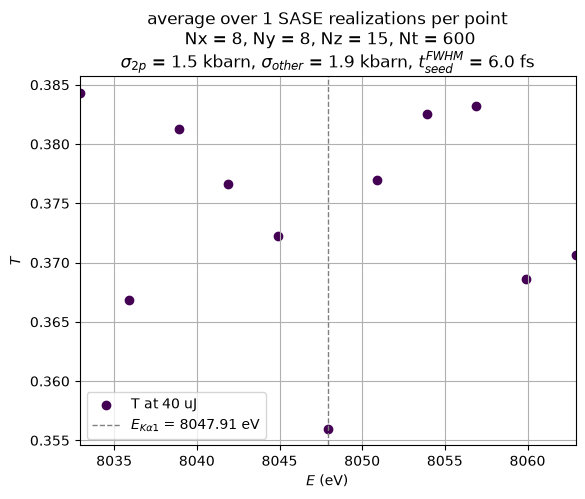

In [ ]:
sorted_accumulated_arrays, aux_data, num_files = data_from_folder(data_path)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, hwKalpha1N = aux_data

plt.figure()

str_pars_grid = " Nx = " + str(xgrid) + ", Ny = " + str(ygrid) + ", Nz = " + str(zgrid) + ", Nt = " + str(tgrid)
str_pars_calc = r'$\sigma_{2p}$ = ' + f'{1e7*sigma1_Ka1_2p3:.1f}' + ' kbarn' + \
r', $\sigma_{other}$ = ' + f'{1e7*sigma1_Ka1_other:.1f}' +' kbarn' + \
r', $t_{seed}^{FWHM}$ = ' + f'{seed_duration_FWHM_t:.1f}' +' fs'

plt.title('average over ' + str(num_files) + ' SASE realizations per point' + '\n'
+ str_pars_grid + '\n' + str_pars_calc
 )

E_seed_values = list(sorted_accumulated_arrays.keys())
norm = plt.matplotlib.colors.LogNorm(vmin=min(E_seed_values), vmax=max(E_seed_values))
cmap = plt.matplotlib.colormaps['viridis']

transmittance_dict = {}

for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():
    energy_values = np.array(sorted(energy_arrays.keys()))
    T_values = np.zeros_like(energy_values)

    for i, energy_value in enumerate(energy_values):
        arrays = energy_arrays[energy_value]
        I_int_thy_w_last = arrays['I_int_thy_w_last']
        I_int_thy_w_0 = arrays['I_int_thy_w_0']

        # Transmittance of a monochromated shot: total transmitted over total
        # incident spectral intensity, integrated over the narrow passband
        # selected by the monochromator at this target energy.
        T_values[i] = np.sum(I_int_thy_w_last) / np.sum(I_int_thy_w_0)

    transmittance_dict[E_seed_value] = (energy_values, T_values)

    plt.scatter(energy_values, T_values, color=cmap(norm(E_seed_value)), label='T at ' + str(E_seed_value) + ' uJ')

plt.axvline(hwKalpha1N, color='gray', ls='--', lw=1, label=r'$E_{K\alpha 1}$' + f' = {hwKalpha1N:.2f} eV')
plt.ylabel(r'$T$')
plt.xlabel(r'$E$ (eV)')
plt.xlim(hwKalpha1N - 15, hwKalpha1N + 15)
plt.legend()
plt.grid(True)
plt.savefig(figs_path + '/mono_' + str_pars_calc + '.pdf')
plt.show()

In [ ]:
min_T = []
area_T = []
FWHM_T = []

for E_seed_value, (energy_values, T_values) in transmittance_dict.items():
    min_T.append(np.min(T_values))

    n_edge = 2
    T_base = 0.5 * (
        np.mean(T_values[:n_edge]) +
        np.mean(T_values[-n_edge:])
    )

    dip = T_base - T_values

    area_T.append(np.trapz(dip, energy_values))
    FWHM_T.append(tools.find_fwhm(energy_values, dip))